# Volume Dataset Unified Benchmark (Greedy + Full + Stochastic)

This notebook runs all solvers with one unified interface:

`VolumeDataset -> VolumeSolver.solve_checked() -> AssignmentSolution -> VolumeDataset.evaluate()`


In [1]:
from pathlib import Path
import sys

REPO_ROOT_BOOT = Path('/Users/igoreshka/Desktop/Optimization-of-flows').resolve()
SRC_PATH = REPO_ROOT_BOOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))
print('Using SRC_PATH:', SRC_PATH)


Using SRC_PATH: /Users/igoreshka/Desktop/Optimization-of-flows/src


In [2]:
from __future__ import annotations

import gzip
import json
import shutil
import time
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from flowopt.volume_core import (
    GreedyBatchConfig,
    GreedyBatchVolumeSolver,
    VolumeDataset,
    VolumeGapVRPLikeSolver,
    VolumeMilpLikeSolver,
    VolumeGeneticLikeSolver,
    VolumeGapVRPStochasticSolver,
    VolumeMilpStochasticSolver,
    VolumeGeneticStochasticSolver,
    assert_dataset_input,
    assert_solution_output,
    save_solution_artifacts,
)


In [3]:
REPO_ROOT = Path('/Users/igoreshka/Desktop/Optimization-of-flows').resolve()
DATA_DIR = REPO_ROOT / 'demo/data/object_volume_feasible_fullfleet/full_all_tasks_all_agents_stage4_volume_only'

CANDIDATE_DATASETS = [
    DATA_DIR / 'dataset_real_spb_clean_full_all_tasks_all_agents_stage4_volume_only_greedy_full_subset_with_distances_v2_100.json',
    DATA_DIR / 'dataset_real_spb_clean_full_all_tasks_all_agents_stage4_volume_only_greedy_full_subset_with_distances.json',
    DATA_DIR / 'dataset_real_spb_clean_full_all_tasks_all_agents_stage4_volume_only_feasible_subset_with_distances.json',
    DATA_DIR / 'dataset_real_spb_clean_full_all_tasks_all_agents_stage4_volume_only.json',
]

DATASET_PATH = next((p for p in CANDIDATE_DATASETS if p.exists()), CANDIDATE_DATASETS[-1])
DATASET_GZ_PATH = (DATA_DIR / 'dataset_real_spb_clean_full_all_tasks_all_agents_stage4_volume_only.json.gz')

OUT_ROOT = REPO_ROOT / 'demo/local/volume_unified_7algo'
OUT_ROOT.mkdir(parents=True, exist_ok=True)
RUN_DIR = OUT_ROOT / f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
RUN_DIR.mkdir(parents=True, exist_ok=True)

# Runtime profile: adjust if you want slower but higher-coverage stochastic runs.
MAX_RUNTIME_SEC = 70.0
TOP_K_AGENTS = 30
TOP_K_DESTINATIONS = 4
MAX_TASKS_IN_TRIP = 500
LOG_EVERY_SEC = 20.0
TRIP_LOG_EVERY = 400

SAVE_DETAILED_ARTIFACTS = False

print('REPO_ROOT:', REPO_ROOT)
print('DATASET_PATH:', DATASET_PATH)
print('RUN_DIR:', RUN_DIR)


REPO_ROOT: /Users/igoreshka/Desktop/Optimization-of-flows
DATASET_PATH: /Users/igoreshka/Desktop/Optimization-of-flows/demo/data/object_volume_feasible_fullfleet/full_all_tasks_all_agents_stage4_volume_only/dataset_real_spb_clean_full_all_tasks_all_agents_stage4_volume_only_greedy_full_subset_with_distances_v2_100.json
RUN_DIR: /Users/igoreshka/Desktop/Optimization-of-flows/demo/local/volume_unified_7algo/run_20260513_001924


In [4]:
if not DATASET_PATH.exists():
    if not DATASET_GZ_PATH.exists():
        raise FileNotFoundError(f'Neither dataset json nor json.gz exists: {DATASET_PATH}')
    print('Unpacking base dataset from .json.gz ...')
    with gzip.open(DATASET_GZ_PATH, 'rb') as src, DATASET_PATH.open('wb') as dst:
        shutil.copyfileobj(src, dst)
    print('Unpacked:', DATASET_PATH)

assert DATASET_PATH.exists(), 'Dataset json must exist after unpacking step.'


In [5]:
base_cfg = GreedyBatchConfig(
    max_runtime_sec=MAX_RUNTIME_SEC,
    top_k_agents=TOP_K_AGENTS,
    top_k_destinations=TOP_K_DESTINATIONS,
    max_tasks_in_trip=MAX_TASKS_IN_TRIP,
    log_every_sec=LOG_EVERY_SEC,
    trip_log_every=TRIP_LOG_EVERY,
    verbose=True,
)

SOLVERS = [
    (
        'greedy_full',
        lambda: GreedyBatchVolumeSolver(
            GreedyBatchConfig(
                max_runtime_sec=MAX_RUNTIME_SEC,
                top_k_agents=TOP_K_AGENTS,
                top_k_destinations=TOP_K_DESTINATIONS,
                max_tasks_in_trip=MAX_TASKS_IN_TRIP,
                log_every_sec=LOG_EVERY_SEC,
                trip_log_every=TRIP_LOG_EVERY,
                verbose=True,
                score_mode='vol_per_km',
                stochastic_mode=False,
                deterministic_fill=True,
            )
        ),
    ),
    ('gap_vrp_like', lambda: VolumeGapVRPLikeSolver(base_cfg)),
    ('milp_like', lambda: VolumeMilpLikeSolver(base_cfg)),
    ('genetic_like', lambda: VolumeGeneticLikeSolver(base_cfg)),
    ('gap_vrp_stoch', lambda: VolumeGapVRPStochasticSolver(base_cfg)),
    ('milp_stoch', lambda: VolumeMilpStochasticSolver(base_cfg)),
    ('genetic_stoch', lambda: VolumeGeneticStochasticSolver(base_cfg)),
]

print('Solvers:', [x[0] for x in SOLVERS])


Solvers: ['greedy_full', 'gap_vrp_like', 'milp_like', 'genetic_like', 'gap_vrp_stoch', 'milp_stoch', 'genetic_stoch']


In [6]:
rows = []
artifacts = {}

for name, solver_factory in SOLVERS:
    print('\n' + '='*20 + f' {name.upper()} START ' + '='*20)
    dataset = VolumeDataset.from_json(DATASET_PATH)
    assert_dataset_input(dataset)

    solver = solver_factory()

    t0 = time.perf_counter()
    if hasattr(solver, 'solve_checked'):
        solution = solver.solve_checked(dataset)
    else:
        solution = solver.solve(dataset)
        solution = assert_solution_output(solution, dataset_path=str(dataset.dataset_path))
    wall = time.perf_counter() - t0

    evaluation = dataset.evaluate(solution)

    out_dir = RUN_DIR / name
    out_dir.mkdir(parents=True, exist_ok=True)
    if SAVE_DETAILED_ARTIFACTS:
        artifacts[name] = save_solution_artifacts(
            dataset=dataset,
            solution=solution,
            evaluation=evaluation,
            out_dir=out_dir,
        )
    else:
        sol_path = out_dir / 'solution.json'
        eval_path = out_dir / 'evaluation.json'
        sol_path.write_text(json.dumps({
            'algorithm': solution.algorithm,
            'dataset_path': solution.dataset_path,
            'runtime_sec': solution.runtime_sec,
            'unassigned_task_ids': list(solution.unassigned_task_ids),
            'trips_count': len(solution.trips),
        }, ensure_ascii=False, indent=2), encoding='utf-8')
        eval_path.write_text(json.dumps(evaluation.as_dict(), ensure_ascii=False, indent=2), encoding='utf-8')
        artifacts[name] = {'solution_json': str(sol_path), 'evaluation_json': str(eval_path)}

    row = evaluation.as_dict()
    row['solver_name'] = name
    row['wall_runtime_sec'] = round(float(wall), 3)
    row['quality_feasible_flag'] = 1.0 if bool(row.get('feasible')) else 0.0
    rows.append(row)

    print(
        f"{name}: assigned={row['assigned_tasks']}/{row['total_tasks']} "
        f"coverage={row['task_coverage_pct']}% feasible={row['feasible']} "
        f"solver_runtime={row['runtime_sec']}s wall={row['wall_runtime_sec']}s"
    )

summary = pd.DataFrame(rows)
summary



==================== GREEDY_FULL START ====================


[volume_core_greedy_batch_v1] start: tasks=29146, agents=786, max_runtime_sec=70.0, top_k_agents=30, top_k_destinations=4, max_tasks_in_trip=500, score_mode=vol_per_km, stochastic_mode=False


[volume_core_greedy_batch_v1] progress: pass=1, assigned=2630/29146 (9.02%), unassigned=26516, trips=20, active_agents=20, pass_trips=20, pass_assigned=2630, pass_agents_with_cands=20, rate_global=126.12 task/s, rate_window=126.12 task/s, eta=210.2s, elapsed=20.9s, avg_tasks/trip=131.50, avg_tasks/active_agent=131.50, avg_trips/active_agent=1.00, avg_km/trip=35.68, avg_h/trip=6.26, avg_payload/trip=61.80, used_agents=20, rem_h<=0.5h:5, rem_h<=1h:5, rem_km<=10:0, rem_km<=25:0, h_util>=90%:5, km_util>=90%:0


[volume_core_greedy_batch_v1] progress: pass=1, assigned=6577/29146 (22.57%), unassigned=22569, trips=53, active_agents=53, pass_trips=53, pass_assigned=6577, pass_agents_with_cands=53, rate_global=160.90 task/s, rate_window=197.11 task/s, eta=140.3s, elapsed=40.9s, avg_tasks/trip=124.09, avg_tasks/active_agent=124.09, avg_trips/active_agent=1.00, avg_km/trip=40.23, avg_h/trip=6.30, avg_payload/trip=63.96, used_agents=53, rem_h<=0.5h:9, rem_h<=1h:10, rem_km<=10:0, rem_km<=25:0, h_util>=90%:10, km_util>=90%:0


[volume_core_greedy_batch_v1] progress: pass=1, assigned=18048/29146 (61.92%), unassigned=11098, trips=178, active_agents=178, pass_trips=178, pass_assigned=18048, pass_agents_with_cands=178, rate_global=296.21 task/s, rate_window=572.05 task/s, eta=37.5s, elapsed=60.9s, avg_tasks/trip=101.39, avg_tasks/active_agent=101.39, avg_trips/active_agent=1.00, avg_km/trip=60.02, avg_h/trip=7.22, avg_payload/trip=50.99, used_agents=178, rem_h<=0.5h:63, rem_h<=1h:65, rem_km<=10:0, rem_km<=25:0, h_util>=90%:65, km_util>=90%:0


...

genetic_like: assigned=28839/29146 coverage=98.947% feasible=False solver_runtime=141.233s wall=141.238s

==================== GAP_VRP_STOCH START ====================


gap_vrp_stoch: assigned=1704/29146 coverage=5.846% feasible=False solver_runtime=27.361s wall=27.367s

==================== MILP_STOCH START ====================


milp_stoch: assigned=1180/29146 coverage=4.049% feasible=False solver_runtime=26.99s wall=26.991s

==================== GENETIC_STOCH START ====================


genetic_stoch: assigned=1052/29146 coverage=3.609% feasible=False solver_runtime=24.805s wall=24.806s


,algorithm,dataset_path,total_tasks,assigned_tasks,unassigned_tasks,task_coverage_pct,active_agents,trips_count,total_km,total_hours,...,runtime_sec,all_checks_ok,feasible,checks,bottlenecks,object_volume_used_m3,object_volume_capacity_m3,solver_name,wall_runtime_sec,quality_feasible_flag
0,volume_core_greedy_batch_v1,/Users/igoreshka/Desktop/Optimization-of-flows...,29146,27006,2140,92.658,346,393,24112.441,2259.732,...,70.002,False,False,"{'all_tasks_assigned': False, 'duplicates': 0,...","{'unassigned_tasks': 2140, 'overflow_km_agents...","{'253734226': 2137.081, '271463269': 1415.559,...","{'253734226': 3572.003, '271463269': 21432.016...",greedy_full,70.009,0.0
1,volume_gap_vrp_like_v1,/Users/igoreshka/Desktop/Optimization-of-flows...,29146,27753,1393,95.221,346,427,26041.262,2385.405,...,70.003,False,False,"{'all_tasks_assigned': False, 'duplicates': 0,...","{'unassigned_tasks': 1393, 'overflow_km_agents...","{'253734226': 2206.943, '271463269': 1700.397,...","{'253734226': 3572.003, '271463269': 21432.016...",gap_vrp_like,70.015,0.0
2,volume_milp_like_v1,/Users/igoreshka/Desktop/Optimization-of-flows...,29146,29015,131,99.551,346,765,45370.168,3090.336,...,67.750,False,False,"{'all_tasks_assigned': False, 'duplicates': 0,...","{'unassigned_tasks': 131, 'overflow_km_agents'...","{'253734226': 2512.295, '271463269': 4627.944,...","{'253734226': 3572.003, '271463269': 21432.016...",milp_like,67.761,0.0
3,volume_genetic_like_v1,/Users/igoreshka/Desktop/Optimization-of-flows...,29146,28839,307,98.947,346,609,37138.386,2775.697,...,141.233,False,False,"{'all_tasks_assigned': False, 'duplicates': 0,...","{'unassigned_tasks': 307, 'overflow_km_agents'...","{'253734226': 2463.165, '271463269': 3188.797,...","{'253734226': 3572.003, '271463269': 21432.016...",genetic_like,141.238,0.0
4,volume_gap_vrp_stoch_v1,/Users/igoreshka/Desktop/Optimization-of-flows...,29146,1704,27442,5.846,16,16,511.381,87.014,...,27.361,False,False,"{'all_tasks_assigned': False, 'duplicates': 0,...","{'unassigned_tasks': 27442, 'overflow_km_agent...","{'253734226': 48.0, '271463269': 0.0, '1743205...","{'253734226': 3572.003, '271463269': 21432.016...",gap_vrp_stoch,27.367,0.0
5,volume_milp_stoch_v1,/Users/igoreshka/Desktop/Optimization-of-flows...,29146,1180,27966,4.049,15,15,451.775,86.679,...,26.990,False,False,"{'all_tasks_assigned': False, 'duplicates': 0,...","{'unassigned_tasks': 27966, 'overflow_km_agent...","{'253734226': 48.0, '271463269': 0.0, '1743205...","{'253734226': 3572.003, '271463269': 21432.016...",milp_stoch,26.991,0.0
6,volume_genetic_stoch_v1,/Users/igoreshka/Desktop/Optimization-of-flows...,29146,1052,28094,3.609,13,13,817.664,35.930,...,24.805,False,False,"{'all_tasks_assigned': False, 'duplicates': 0,...","{'unassigned_tasks': 28094, 'overflow_km_agent...","{'253734226': 123.992, '271463269': 48.0, '174...","{'253734226': 3572.003, '271463269': 21432.016...",genetic_stoch,24.806,0.0


In [7]:
# Unified quality metric for ranking
# Higher is better.

s = summary.copy()

cov = s['task_coverage_pct'].astype(float) / 100.0
feas = s['feasible'].astype(bool).astype(float)
wall = s['wall_runtime_sec'].astype(float)

# Min-max normalize for cost-like metrics (lower is better)
def inv_minmax(x: pd.Series) -> pd.Series:
    x = x.astype(float)
    lo, hi = float(x.min()), float(x.max())
    if hi - lo < 1e-12:
        return pd.Series(np.ones(len(x)), index=x.index)
    return 1.0 - (x - lo) / (hi - lo)

runtime_score = inv_minmax(wall)
km_score = inv_minmax(s['total_km'].fillna(s['total_km'].max()))
tr_score = inv_minmax(s['transport_work_volume_m3_km'].fillna(s['transport_work_volume_m3_km'].max()))

s['quality_score'] = (
    0.55 * cov
    + 0.20 * feas
    + 0.15 * runtime_score
    + 0.05 * km_score
    + 0.05 * tr_score
)

sort_cols = ['quality_score', 'task_coverage_pct', 'feasible', 'wall_runtime_sec']
s = s.sort_values(sort_cols, ascending=[False, False, False, True]).reset_index(drop=True)

summary_path_csv = RUN_DIR / 'summary_all_algorithms.csv'
summary_path_json = RUN_DIR / 'summary_all_algorithms.json'
s.to_csv(summary_path_csv, index=False)
summary_path_json.write_text(s.to_json(orient='records', force_ascii=False, indent=2), encoding='utf-8')

print('Saved:', summary_path_csv)
print('Saved:', summary_path_json)

view_cols = [
    'solver_name', 'algorithm', 'feasible', 'all_checks_ok',
    'assigned_tasks', 'unassigned_tasks', 'task_coverage_pct',
    'active_agents', 'trips_count', 'transport_work_volume_m3_km',
    'total_km', 'total_hours', 'runtime_sec', 'wall_runtime_sec', 'quality_score'
]
s[view_cols]


Saved: /Users/igoreshka/Desktop/Optimization-of-flows/demo/local/volume_unified_7algo/run_20260513_001924/summary_all_algorithms.csv
Saved: /Users/igoreshka/Desktop/Optimization-of-flows/demo/local/volume_unified_7algo/run_20260513_001924/summary_all_algorithms.json


,solver_name,algorithm,feasible,all_checks_ok,assigned_tasks,unassigned_tasks,task_coverage_pct,active_agents,trips_count,transport_work_volume_m3_km,total_km,total_hours,runtime_sec,wall_runtime_sec,quality_score
0,gap_vrp_like,volume_gap_vrp_like_v1,False,False,27753,1393,95.221,346,427,347903.470,26041.262,2385.405,70.003,70.015,0.644139
1,milp_like,volume_milp_like_v1,False,False,29015,131,99.551,346,765,404728.598,45370.168,3090.336,67.750,67.761,0.642191
2,greedy_full,volume_core_greedy_batch_v1,False,False,27006,2140,92.658,346,393,337959.898,24112.441,2259.732,70.002,70.009,0.633448
3,genetic_like,volume_genetic_like_v1,False,False,28839,307,98.947,346,609,394930.201,37138.386,2775.697,141.233,141.238,0.554605
4,gap_vrp_stoch,volume_gap_vrp_stoch_v1,False,False,1704,27442,5.846,16,16,10582.451,511.381,87.014,27.361,27.367,0.278386
5,milp_stoch,volume_milp_stoch_v1,False,False,1180,27966,4.049,15,15,7393.391,451.775,86.679,26.990,26.991,0.269455
6,genetic_stoch,volume_genetic_stoch_v1,False,False,1052,28094,3.609,13,13,23565.755,817.664,35.930,24.805,24.806,0.267407


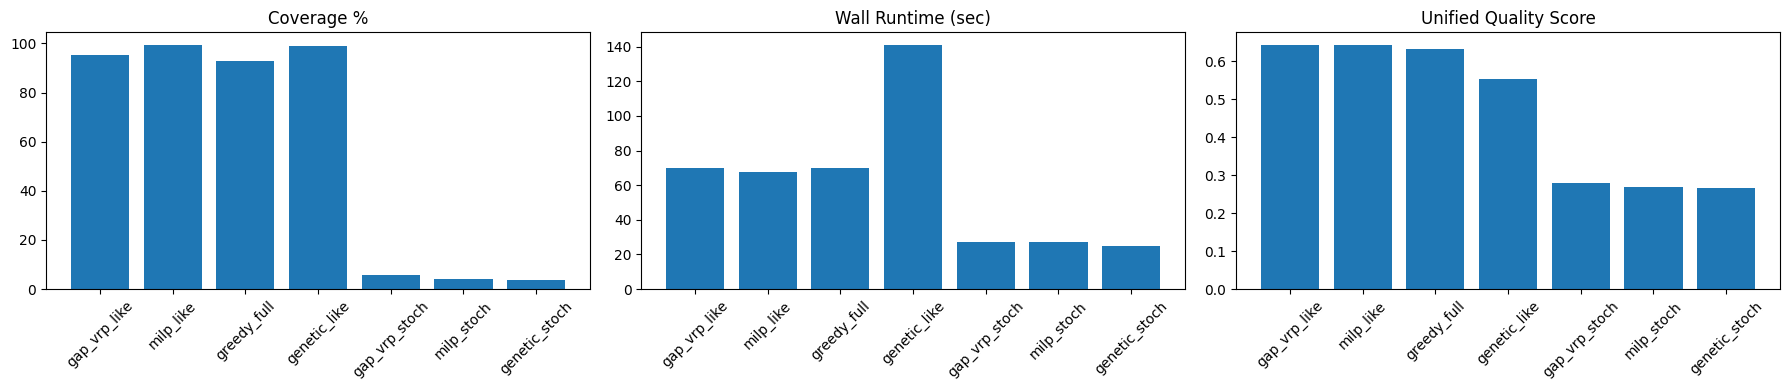

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

plot_df = s.copy()
labels = plot_df['solver_name'].tolist()

axes[0].bar(labels, plot_df['task_coverage_pct'])
axes[0].set_title('Coverage %')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(labels, plot_df['wall_runtime_sec'])
axes[1].set_title('Wall Runtime (sec)')
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(labels, plot_df['quality_score'])
axes[2].set_title('Unified Quality Score')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [9]:
print('Run dir:', RUN_DIR)
print('Artifacts index sample:')
for k, v in artifacts.items():
    print(k, '->', v.get('solution_json', 'n/a'))


Run dir: /Users/igoreshka/Desktop/Optimization-of-flows/demo/local/volume_unified_7algo/run_20260513_001924
Artifacts index sample:
greedy_full -> /Users/igoreshka/Desktop/Optimization-of-flows/demo/local/volume_unified_7algo/run_20260513_001924/greedy_full/solution.json
gap_vrp_like -> /Users/igoreshka/Desktop/Optimization-of-flows/demo/local/volume_unified_7algo/run_20260513_001924/gap_vrp_like/solution.json
milp_like -> /Users/igoreshka/Desktop/Optimization-of-flows/demo/local/volume_unified_7algo/run_20260513_001924/milp_like/solution.json
genetic_like -> /Users/igoreshka/Desktop/Optimization-of-flows/demo/local/volume_unified_7algo/run_20260513_001924/genetic_like/solution.json
gap_vrp_stoch -> /Users/igoreshka/Desktop/Optimization-of-flows/demo/local/volume_unified_7algo/run_20260513_001924/gap_vrp_stoch/solution.json
milp_stoch -> /Users/igoreshka/Desktop/Optimization-of-flows/demo/local/volume_unified_7algo/run_20260513_001924/milp_stoch/solution.json
genetic_stoch -> /Users/ig